# 3.2 Clustering

## Importar paquetes

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Carga de datos

In [2]:
df = pd.read_csv('./data/retailmax.csv')

## Selección de features

Nos enfocaremos primero en las variables numéricas para construir los clusters, y luego podremos incorporar el sexo para un análisis más detallado.

In [3]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [4]:
df.sample(5, random_state=42)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
95,96,Male,24,60,52
15,16,Male,22,20,79
30,31,Male,60,30,4
158,159,Male,34,78,1
128,129,Male,59,71,11


In [5]:
features.sample(5, random_state=42)

,Age,Annual Income (k$),Spending Score (1-100)
95,24,60,52
15,22,20,79
30,60,30,4
158,34,78,1
128,59,71,11


## Estandarización

In [6]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

## Inspección rápida

In [7]:
type(scaled_features)

numpy.ndarray

In [8]:
scaled_features.shape

(200, 3)

In [9]:
scaled_features[0:3]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298]])

## Creación de clusters

In [10]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

In [11]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

In [12]:
kmeans

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 3)","[[ 0.

In [13]:
clusters

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

## Visualización de clusters

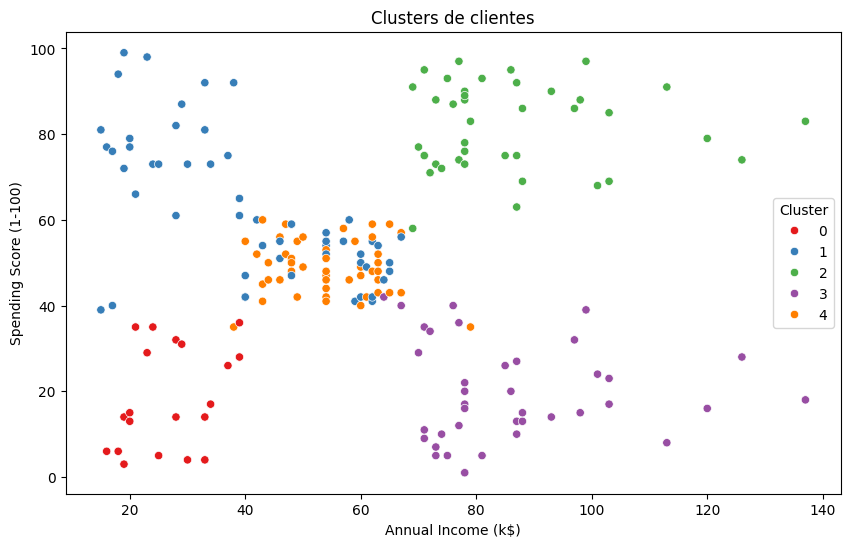

In [14]:
df['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set1')
plt.title('Clusters de clientes')
plt.show()

## Optimización: Método del Codo (Elbow Method)

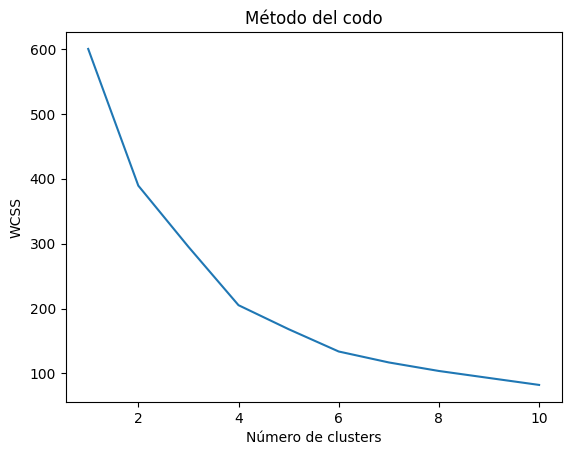

In [15]:
# Función para calcular la Suma de Cuadrados Dentro del Cluster (WCSS)
def calcular_wcss(datos):
    wcss = []
    for n in range(1, 11):
        kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=42)
        kmeans.fit(datos)
        wcss.append(kmeans.inertia_)
    return wcss

# Calcular el WCSS para diferentes números de clusters
wcss = calcular_wcss(scaled_features)

# Graficar el método del codo
plt.plot(range(1, 11), wcss)
plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

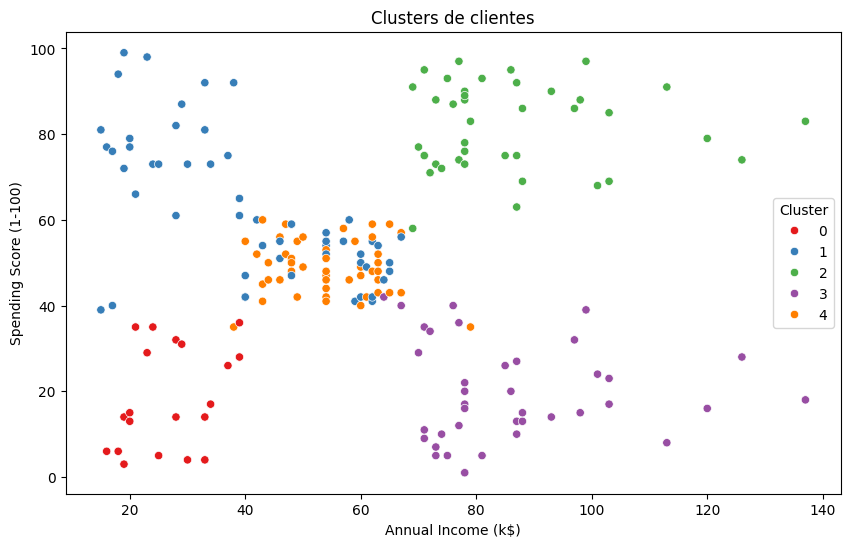

In [16]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
df['Cluster'] = clusters

# mostrar gráfica
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set1')
plt.title('Clusters de clientes')
plt.show()

## Visualización 3D

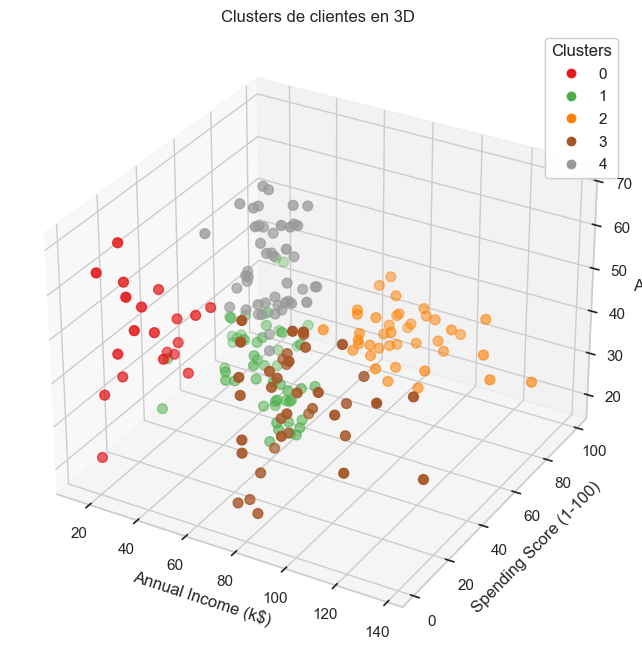

In [17]:
from mpl_toolkits.mplot3d import Axes3D

# Configurar el estilo de Seaborn
sns.set(style="whitegrid")

# Crear una figura en 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Gráfico 3D de dispersión
scatter = ax.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], df['Age'],
                     c=df['Cluster'], cmap='Set1', s=50)

# Etiquetas de los ejes
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')

# Título de la gráfica
ax.set_title('Clusters de clientes en 3D')

# Añadir la leyenda
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

# Mostrar la gráfica
plt.show()

## Análisis final

In [18]:
cluster_analysis = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].groupby('Cluster').mean()
cluster_analysis

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


In [19]:
for cluster in cluster_analysis.index:
    print(f"Cluster {cluster}:")
    print(f" - Edad media: {cluster_analysis['Age'][cluster]:.2f}")
    print(f" - Ingreso anual medio: {cluster_analysis['Annual Income (k$)'][cluster]:.2f}k$")
    print(f" - Calificación RetailMax: {cluster_analysis['Spending Score (1-100)'][cluster]:.2f}")
    print("===========================================")

Cluster 0:
 - Edad media: 46.25
 - Ingreso anual medio: 26.75k$
 - Calificación RetailMax: 18.35
Cluster 1:
 - Edad media: 25.19
 - Ingreso anual medio: 41.09k$
 - Calificación RetailMax: 62.24
Cluster 2:
 - Edad media: 32.88
 - Ingreso anual medio: 86.10k$
 - Calificación RetailMax: 81.53
Cluster 3:
 - Edad media: 39.87
 - Ingreso anual medio: 86.10k$
 - Calificación RetailMax: 19.36
Cluster 4:
 - Edad media: 55.64
 - Ingreso anual medio: 54.38k$
 - Calificación RetailMax: 48.85


## Incorporando la variable "sexo"

In [20]:
# Convertir a numérica
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# selección de features
extended_features = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# estandarización
scaled_extended_features = scaler.fit_transform(extended_features)

# Aplicar K-Means
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters_extended = kmeans.fit_predict(scaled_extended_features)

# Sustituir clusters anteriores
df['Cluster'] = clusters_extended

# análisis
extended_cluster_analysis = df[['Gender','Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].groupby('Cluster').mean()
extended_cluster_analysis

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.538462,32.692308,86.538462,82.128205
1,0.551724,36.482759,89.517241,18.000000
2,1.000000,49.813953,49.232558,40.069767
3,0.592593,24.907407,39.722222,61.203704
4,0.000000,55.714286,53.685714,36.771429
